In [1]:
import os
import sys
import glob
import awkward as ak
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import uproot
import math

In [2]:
background_inf_paths = glob.glob(os.path.join('/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/', "bk*"))
signal_inf_paths = glob.glob(os.path.join('/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/signal/', 'v*'))
signal_inf_paths

['/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/signal/validation_inference_010.npz',
 '/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/signal/validation_inference_050.npz',
 '/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/signal/validation_inference_005.npz',
 '/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/signal/validation_inference_100.npz']

In [5]:
#load in each of the signal mass point arrays
m010_inference_arr = (np.load(signal_inf_paths[0]))['inference_info']
m050_inference_arr = (np.load(signal_inf_paths[1]))['inference_info']
m005_inference_arr = (np.load(signal_inf_paths[2]))['inference_info']
m100_inference_arr = (np.load(signal_inf_paths[3]))['inference_info']
print(len(m100_inference_arr))

#now we can stack the arrays from our background
bkgd_arr_list = []
for file in background_inf_paths:
    arr = (np.load(file))['inference_info']
    bkgd_arr_list.append(arr)

27961


In [4]:
#Create a stacked array
bkgd_arr = np.vstack(bkgd_arr_list)
print(len(bkgd_arr[:,0]))


7332998


In [5]:
#Now create stacks for each roc curve
m010_roc_arr = np.vstack((m010_inference_arr, bkgd_arr))
m050_roc_arr = np.vstack((m050_inference_arr, bkgd_arr))
m005_roc_arr = np.vstack((m005_inference_arr, bkgd_arr))
m100_roc_arr = np.vstack((m100_inference_arr, bkgd_arr))

In [6]:
#We can now create ROC curves (dynamic score, static, truth)
fpr100_d, tpr100_d, thresholds100_d = roc_curve(m100_roc_arr[:,2], m100_roc_arr[:,0])
roc_auc_100_d = auc(fpr100_d, tpr100_d)

fpr005_d, tpr005_d, thresholds005_d = roc_curve(m005_roc_arr[:,2], m005_roc_arr[:,0])
roc_auc_005_d = auc(fpr005_d, tpr005_d)

fpr010_d, tpr010_d, thresholds010_d = roc_curve(m010_roc_arr[:,2], m010_roc_arr[:,0])
roc_auc_010_d = auc(fpr010_d, tpr010_d)

fpr050_d, tpr050_d, thresholds050_d = roc_curve(m050_roc_arr[:,2], m050_roc_arr[:,0])
roc_auc_050_d = auc(fpr050_d, tpr050_d)

In [6]:
plt.plot(fpr100_d, tpr100_d, label = f'dynamic model\nauc: {roc_auc_100_d:.7f}', lw = 2, color = 3)
plt.plot(fpr050_d, tpr050_d, label = f'dynamic model\nauc: {roc_auc_050_d:.7f}', lw = 2, color = 2)
plt.plot(fpr010_d, tpr010_d, label = f'dynamic model\nauc: {roc_auc_010_d:.7f}', lw = 2, color = 1)
plt.plot(fpr005_d, tpr005_d, label = f'dynamic model\nauc: {roc_auc_005_d:.7f}', lw = 2, color = 0)
plt.legend()
plt.xscale('log')
plt.xlabel('False Signal Rate')
plt.ylabel('True Signal Rate')
plt.title('Deeper ROC Curve Comparison (Static, Dynamic), 100 MeV Signal')

NameError: name 'fpr100_d' is not defined

In [8]:
threshold = 0.999999
remaining_bkgd = bkgd_arr[bkgd_arr[:,0] > threshold]
print(len(remaining_bkgd))
sig_eff_100 = len(m100_inference_arr[m100_inference_arr[:,0] > threshold]) / len(m100_inference_arr)
sig_eff_050 = len(m050_inference_arr[m050_inference_arr[:,0] > threshold]) / len(m050_inference_arr)
sig_eff_010 = len(m010_inference_arr[m010_inference_arr[:,0] > threshold]) / len(m010_inference_arr)
sig_eff_005 = len(m005_inference_arr[m005_inference_arr[:,0] > threshold]) / len(m005_inference_arr)
file_numbers = (remaining_bkgd[:,-1])
event_numbers = remaining_bkgd[:,3]
print(sig_eff_100)
print(sig_eff_050)
print(sig_eff_010)
print(sig_eff_005)
print(file_numbers)
print(event_numbers)
print(remaining_bkgd[:,0])
print(remaining_bkgd[:,1])

12
0.33192661206680735
0.34510299963859775
0.3507659037664444
0.32898415657036345
[ 2915. 51757.  8190.  7909. 10896. 15032.  5740.   925. 61493. 54473.
  9085. 52538.]
[ 379.  329. 1443.  230.  750. 1458.  224.   94. 1672. 1508. 2429. 2740.]
[0.99999928 0.99999952 0.9999994  0.99999964 1.         0.99999952
 0.99999917 0.99999964 0.99999905 0.99999917 1.         0.99999976]
[1.         1.         0.99999976 0.99999976 1.         1.
 1.         1.         1.         0.99999905 1.         0.99999988]


In [26]:
#file_path = '/standard/ldmxuva/EaT_background_8gev/eat_note_run_2026/EaT_eot_equivalent_enriched/enriched_nuclear_MaxEvents_5000000_skim_True_run_61493.root'
file_path = '/standard/ldmxuva/gnn_files/note_stuff/validation_root/signal/category_signal_Nevents_40000_MaxTries_10k_mAMeV_0100_epsilon_0.01_minApE_4000_minPrimEatEcal_7000_run_104000.root'
root = uproot.open(file_path)
tree = root['LDMX_Events']
#sims['SimParticles_eat.second.px_'].array()
#so what are the branches that we want? ECal hit x, y, z, E; HCal hit x, y, z, E; Sim_Particle pgdid, vtx x,y,z end x,y,z
#background tags
"""
sims = tree["SimParticles_eat"]
branches = ['SimParticles_eat.second.vtx_x_',
 'SimParticles_eat.second.vtx_y_',
 'SimParticles_eat.second.vtx_z_',
 'SimParticles_eat.second.end_x_',
 'SimParticles_eat.second.end_y_',
 'SimParticles_eat.second.end_z_', 
 'SimParticles_eat.second.pdg_id_',
 'SimParticles_eat.second.parents_',
 'EcalRecHits_eat.energy_',
 'HcalRecHits_eat.layer_',
 'EcalRecHits_eat.time_',
 'EcalRecHits_eat.xpos_',
 'EcalRecHits_eat.ypos_',
 'EcalRecHits_eat.zpos_', 
 'HcalRecHits_eat.xpos_',
 'HcalRecHits_eat.ypos_',
 'HcalRecHits_eat.zpos_', 
 'HcalRecHits_eat.energy_' ]
"""
#signal tags

sims = tree["SimParticles_eat_vis"]
branches = ['SimParticles_eat_vis.second.vtx_x_',
 'SimParticles_eat_vis.second.vtx_y_',
 'SimParticles_eat_vis.second.vtx_z_',
 'SimParticles_eat_vis.second.end_x_',
 'SimParticles_eat_vis.second.end_y_',
 'SimParticles_eat_vis.second.end_z_', 
 'SimParticles_eat_vis.second.pdg_id_',
 'SimParticles_eat_vis.second.parents_',
 'EcalRecHits_eat_vis.energy_',
 'HcalRecHits_eat_vis.section_',
 'HcalRecHits_eat_vis.layer_',
 'EcalRecHits_eat_vis.time_',
 'EcalRecHits_eat_vis.xpos_',
 'EcalRecHits_eat_vis.ypos_',
 'EcalRecHits_eat_vis.zpos_', 
 'HcalRecHits_eat_vis.xpos_',
 'HcalRecHits_eat_vis.ypos_',
 'HcalRecHits_eat_vis.zpos_', 
 'HcalRecHits_eat_vis.energy_' ]

event_number = 1672
data = (tree.arrays(branches))[event_number] #index with the event number

In [10]:
#background
"""
vtx_x = ak.to_numpy(data['SimParticles_eat.second.vtx_x_'])
vtx_y = ak.to_numpy(data['SimParticles_eat.second.vtx_y_'])
vtx_z = ak.to_numpy(data['SimParticles_eat.second.vtx_z_'])

parents = ak.to_numpy(data['SimParticles_eat.second.parents_'])

end_x = ak.to_numpy(data['SimParticles_eat.second.end_x_'])
end_y = ak.to_numpy(data['SimParticles_eat.second.end_y_'])
end_z = ak.to_numpy(data['SimParticles_eat.second.end_z_'])

pdgid = ak.to_numpy(data['SimParticles_eat.second.pdg_id_'])

e_hit = np.column_stack((ak.to_numpy(data['EcalRecHits_eat.xpos_']), 
                        ak.to_numpy(data['EcalRecHits_eat.ypos_']),
                        ak.to_numpy(data['EcalRecHits_eat.zpos_']),
                        ak.to_numpy(data['EcalRecHits_eat.energy_'])))

h_hit = np.column_stack((ak.to_numpy(data['HcalRecHits_eat.xpos_']), 
                        ak.to_numpy(data['HcalRecHits_eat.ypos_']),
                        ak.to_numpy(data['HcalRecHits_eat.zpos_']),
                        ak.to_numpy(data['HcalRecHits_eat.energy_']) * 12))

h_layer = ak.to_numpy(data['HcalRecHits_eat.layer_'])
print(min(h_layer))
"""
#signal
vtx_x = ak.to_numpy(data['SimParticles_eat_vis.second.vtx_x_'])
vtx_y = ak.to_numpy(data['SimParticles_eat_vis.second.vtx_y_'])
vtx_z = ak.to_numpy(data['SimParticles_eat_vis.second.vtx_z_'])

parents = ak.to_numpy(data['SimParticles_eat_vis.second.parents_'])

end_x = ak.to_numpy(data['SimParticles_eat_vis.second.end_x_'])
end_y = ak.to_numpy(data['SimParticles_eat_vis.second.end_y_'])
end_z = ak.to_numpy(data['SimParticles_eat_vis.second.end_z_'])

pdgid = ak.to_numpy(data['SimParticles_eat_vis.second.pdg_id_'])

e_hit = np.column_stack((ak.to_numpy(data['EcalRecHits_eat_vis.xpos_']), 
                        ak.to_numpy(data['EcalRecHits_eat_vis.ypos_']),
                        ak.to_numpy(data['EcalRecHits_eat_vis.zpos_']),
                        ak.to_numpy(data['EcalRecHits_eat_vis.energy_'])))

h_hit = np.column_stack((ak.to_numpy(data['HcalRecHits_eat_vis.xpos_']), 
                        ak.to_numpy(data['HcalRecHits_eat_vis.ypos_']),
                        ak.to_numpy(data['HcalRecHits_eat_vis.zpos_']),
                        ak.to_numpy(data['HcalRecHits_eat_vis.energy_']) * 12))

h_layer = ak.to_numpy(data['HcalRecHits_eat_vis.layer_'])
print(min(h_layer))

55


In [11]:
def trackcolor(pdgid):
    c = 'black' # black track by default
    if pdgid == 2212:
        c = 'red' # proton == red
    if pdgid == 2112:
        c = 'green' # neutron == green
    if pdgid == 211:
        c = 'magenta' # pi+ == magenta
    if pdgid == -211:
        c = 'cyan' # pi- == cyan
    if pdgid == 22:
        c = 'gold' # photon == gold
    if pdgid == 130:
        c = 'orange' # K-long == orange
    if pdgid == 310:
        c = 'darkred' # K-short == dark red
    if pdgid == 321:
        c = 'violet' # K+ == violet
    if pdgid == -321:
        c = 'powderblue' # K- == powder blue
    if pdgid == 11:
        c = 'blue' # electron == blue
    if pdgid == -11:
        c = 'pink' #positron == pink
    if pdgid == 622:
        c = 'lightgreen'    
    return c

# wireframe rending of the ecal coordinates. This is a work of art by Matt Solt
def hex_coords(ax, center = [0,0], rad=85):
    
    x1 = [center[0]+rad, center[0]+rad/2, center[0]-rad/2, center[0]-rad, center[0]-rad/2, center[0]+rad/2, center[0]+rad]
    y1 = [center[1], center[1]+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2, center[1], center[1]-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2, center[1]]
    
    x2 = [center[0]+rad*3/2+rad, center[0]+rad*3/2+rad/2, center[0]+rad*3/2-rad/2, center[0]+rad*3/2-rad, center[0]+rad*3/2-rad/2, center[0]+rad*3/2+rad/2, center[0]+rad*3/2+rad]
    y2 = [center[1]+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2]
    
    x3 = [center[0]+rad, center[0]+rad/2, center[0]-rad/2, center[0]-rad, center[0]-rad/2, center[0]+rad/2, center[0]+rad]
    y3 = [center[1]+rad*math.sqrt(3), center[1]+rad*math.sqrt(3)+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3), center[1]+rad*math.sqrt(3)-rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)-rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)]
    
    x4 = [center[0]-rad*3/2+rad, center[0]-rad*3/2+rad/2, center[0]-rad*3/2-rad/2, center[0]-rad*3/2-rad, center[0]-rad*3/2-rad/2, center[0]-rad*3/2+rad/2, center[0]-rad*3/2+rad]
    y4 = [center[1]+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]+rad*math.sqrt(3)/2]
    
    x5 = [center[0]-rad*3/2+rad, center[0]-rad*3/2+rad/2, center[0]-rad*3/2-rad/2, center[0]-rad*3/2-rad, center[0]-rad*3/2-rad/2, center[0]-rad*3/2+rad/2, center[0]-rad*3/2+rad]
    y5 = [center[1]-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2+rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2]
    
    x6 = [center[0]+rad, center[0]+rad/2, center[0]-rad/2, center[0]-rad, center[0]-rad/2, center[0]+rad/2, center[0]+rad]
    y6 = [center[1]-rad*math.sqrt(3), center[1]-rad*math.sqrt(3)+rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)+rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3), center[1]-rad*math.sqrt(3)-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)]

    x7 = [center[0]+rad*3/2+rad, center[0]+rad*3/2+rad/2, center[0]+rad*3/2-rad/2, center[0]+rad*3/2-rad, center[0]+rad*3/2-rad/2, center[0]+rad*3/2+rad/2, center[0]+rad*3/2+rad]
    y7 = [center[1]-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2+rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2+rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2-rad*math.sqrt(3)/2, center[1]-rad*math.sqrt(3)/2]
    
    z1 = [250,250,250,250,250,250,250]
    z2 = [750,750,750,750,750,750,750]
    
    for i in range(7):
        xl1 = [x1[i],x1[i]]
        xl2 = [x2[i],x2[i]]
        xl3 = [x3[i],x3[i]]
        xl4 = [x4[i],x4[i]]
        xl5 = [x5[i],x5[i]]
        xl6 = [x6[i],x6[i]]
        xl7 = [x7[i],x7[i]]
        
        yl1 = [y1[i],y1[i]]
        yl2 = [y2[i],y2[i]]
        yl3 = [y3[i],y3[i]]
        yl4 = [y4[i],y4[i]]
        yl5 = [y5[i],y5[i]]
        yl6 = [y6[i],y6[i]]
        yl7 = [y7[i],y7[i]]
        
        z = [250,750]
        
        ax.plot(z,xl1,yl1, color='k',linewidth=1/4)
        ax.plot(z,xl2,yl2, color='k',linewidth=1/4)
        ax.plot(z,xl3,yl3, color='k',linewidth=1/4)
        ax.plot(z,xl4,yl4, color='k',linewidth=1/4)
        ax.plot(z,xl5,yl5, color='k',linewidth=1/4)
        ax.plot(z,xl6,yl6, color='k',linewidth=1/4)
        ax.plot(z,xl7,yl7, color='k',linewidth=1/4)
    
    ax.plot(z1,x1,y1, color='k',linewidth=1/4)
    ax.plot(z1,x2,y2, color='k',linewidth=1/4)
    ax.plot(z1,x3,y3, color='k',linewidth=1/4)
    ax.plot(z1,x4,y4, color='k',linewidth=1/4)
    ax.plot(z1,x5,y5, color='k',linewidth=1/4)
    ax.plot(z1,x6,y6, color='k',linewidth=1/4)
    ax.plot(z1,x7,y7, color='k',linewidth=1/4)
    ax.plot(z2,x1,y1, color='k',linewidth=1/4)
    ax.plot(z2,x2,y2, color='k',linewidth=1/4)
    ax.plot(z2,x3,y3, color='k',linewidth=1/4)
    ax.plot(z2,x4,y4, color='k',linewidth=1/4)
    ax.plot(z2,x5,y5, color='k',linewidth=1/4)
    ax.plot(z2,x6,y6, color='k',linewidth=1/4)
    ax.plot(z2,x7,y7, color='k',linewidth=1/4)

Text(0.5, 0.92, 'Event 1672 Display')

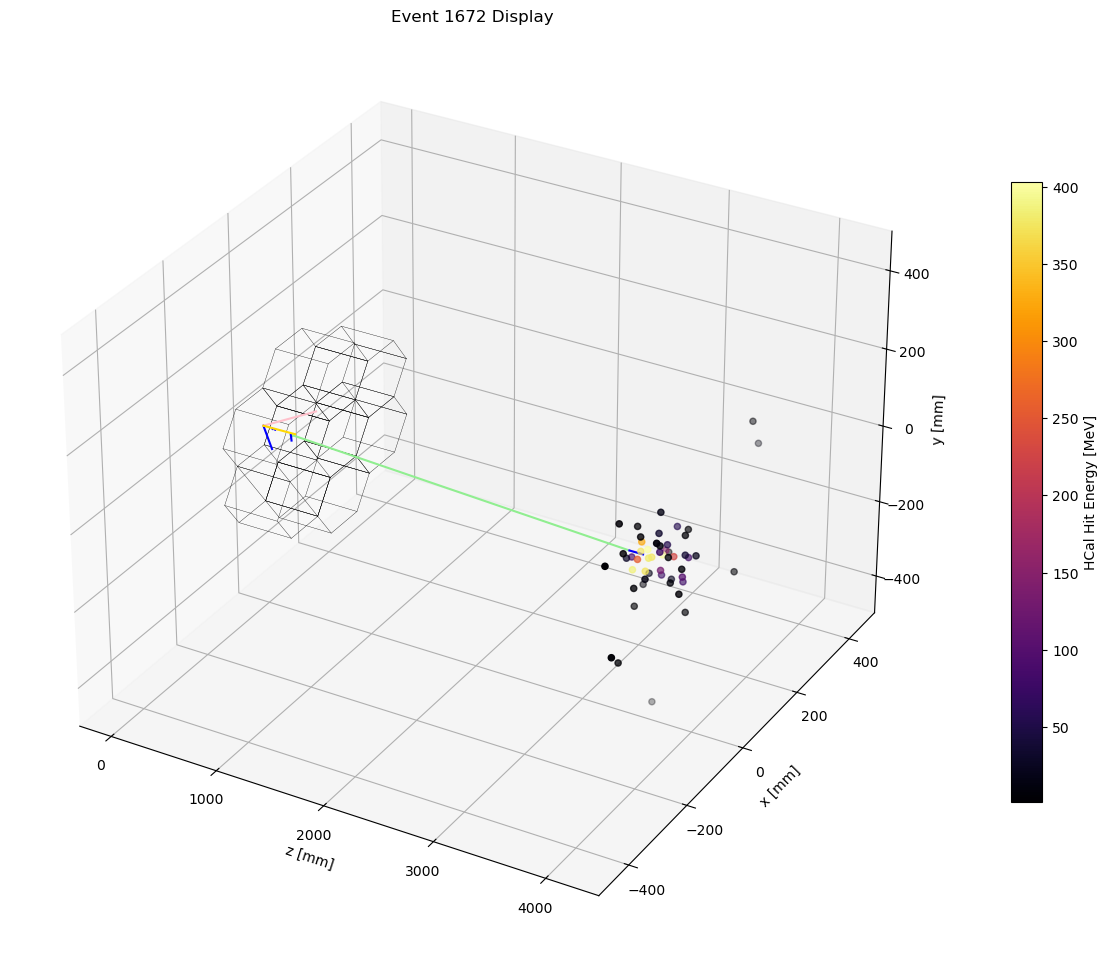

In [12]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize = (20,12))
ax = fig.add_subplot(111, projection='3d')
#plot the ECal
hex_coords(ax)
#plot the lines
for i in range(len(vtx_x)):
    if vtx_z[i] > 0:
        dist = np.sqrt((end_x[i] - vtx_x[i])**2 + (end_y[i] - vtx_y[i])**2 + (end_z[i] - vtx_z[i])**2 )
        if dist > 0.5 and dist < 5000: #tracks > 0.5 mm
            xs = [vtx_x[i], end_x[i]]
            ys = [vtx_y[i], end_y[i]]
            zs = [vtx_z[i], end_z[i]]
            ax.plot(zs, xs, ys, color = trackcolor(pdgid[i]))
            #ax.set_xlim((-15,2500))
            ax.set_ylim((-500,500))
            ax.set_zlim((-500,500))
            ax.set_xlabel("z [mm]")
            ax.set_ylabel("x [mm]")
            ax.set_zlabel("y [mm]")
            #ax.view_init(elev=30, azim=-60)

#plot the ECal hits
#ecal = ax.scatter(e_hit[:,2], e_hit[:,0], e_hit[:,1], c = e_hit[:,3], cmap = 'viridis')
hcal = ax.scatter(h_hit[:,2], h_hit[:,0], h_hit[:,1], c = h_hit[:,3], cmap = 'inferno')

#fig.colorbar(ecal, fraction = 0.02, label  = 'ECal Hit Energy [MeV]')
fig.colorbar(hcal, fraction = 0.02, label = 'HCal Hit Energy [MeV]')

ax.set_title(f"Event {event_number} Display")

In [28]:
threshold = 0.99999
remaining_bkgd = bkgd_arr[bkgd_arr[:,0] > threshold]
print(len(remaining_bkgd))
sig_eff_100 = len(m100_inference_arr[m100_inference_arr[:,0] > threshold]) / len(m100_inference_arr)
sig_eff_050 = len(m050_inference_arr[m050_inference_arr[:,0] > threshold]) / len(m050_inference_arr)
sig_eff_010 = len(m010_inference_arr[m010_inference_arr[:,0] > threshold]) / len(m010_inference_arr)
sig_eff_005 = len(m005_inference_arr[m005_inference_arr[:,0] > threshold]) / len(m005_inference_arr)
file_numbers = (remaining_bkgd[:,-1])
event_numbers = remaining_bkgd[:,3]
#print(sig_eff_100)
#print(sig_eff_050)
#print(sig_eff_010)
#print(sig_eff_005)
#print(file_numbers)
#print(event_numbers)
event_numbers_signal = (m100_inference_arr[m100_inference_arr[:,0] > threshold])[:,3]

88


array([34087.,  8368., 23090., ...,  3840., 23138., 14579.],
      shape=(18609,))

In [39]:
min_layers = []
for i, file_number in enumerate(file_numbers):
    file_number = int(file_number)
    #find the file
    if file_number < 12000:
        path = '/standard/ldmxuva/EaT_background_8gev/eat_note_run_2026/enriched_nuclear/'
    elif file_number < 17000:
        path = '/standard/ldmxuva/EaT_background_8gev/eat_note_run_2026/enriched_nuclear/supplemental/'
    elif file_number < 70000:
        path = '/standard/ldmxuva/EaT_background_8gev/eat_note_run_2026/EaT_eot_equivalent_enriched/'

    full_path = (glob.glob(os.path.join(path, f'*_{file_number}.root')))[0]
    event_number = int(event_numbers[i])
    #open and grab the relevant event 
    root = uproot.open(full_path)
    tree = root['LDMX_Events']
    data = (tree.arrays(['HcalRecHits_eat.section_','HcalRecHits_eat.layer_']))[event_number]
    sections = ak.to_numpy(data['HcalRecHits_eat.section_'])
    layers = ak.to_numpy(data['HcalRecHits_eat.layer_'])
    data_stack = np.column_stack((sections, layers))
    relevant_layers = data_stack[data_stack[:,0] == 0]
    minimum_layer = min(relevant_layers[:,1])
    min_layers.append(minimum_layer)

In [40]:
#now we can load in the signal in a similar manner. 
file_path = '/standard/ldmxuva/gnn_files/note_stuff/validation_root/signal/category_signal_Nevents_40000_MaxTries_10k_mAMeV_0100_epsilon_0.01_minApE_4000_minPrimEatEcal_7000_run_104000.root'
root = uproot.open(file_path)
tree = root['LDMX_Events']
min_layers_signal = []
data = (tree.arrays(['HcalRecHits_eat_vis.section_','HcalRecHits_eat_vis.layer_']))
for event_number_signal in event_numbers_signal:
    event_data = data[int(event_number_signal)]
    sections = ak.to_numpy(event_data['HcalRecHits_eat_vis.section_'])
    layers = ak.to_numpy(event_data['HcalRecHits_eat_vis.layer_'])
    data_stack = np.column_stack((sections, layers))
    relevant_layers = data_stack[data_stack[:,0] == 0]
    minimum_layer = min(relevant_layers[:,1])
    min_layers_signal.append(minimum_layer)

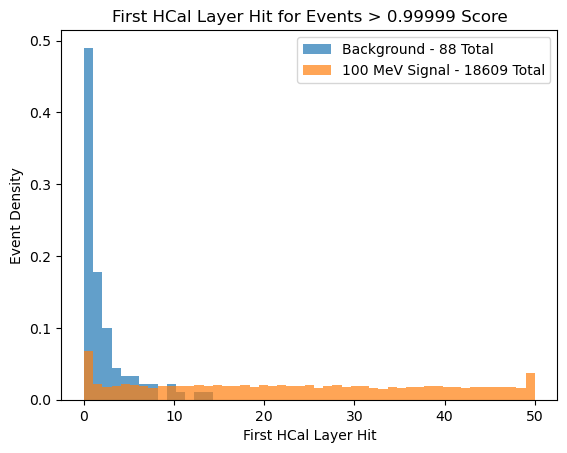

In [52]:
#This is just a function of our uniform decaying signal though...
#But this is more or less what we expect. 
#It is pretty cool that the GNN can learn things about displacement it seems. All z values are z-scored away of course. 
bins = np.linspace(0, 50, 50)
plt.hist(min_layers, bins = bins, density = True, alpha = 0.7, label = f'Background - {len(min_layers)} Total')
plt.hist(min_layers_signal, bins = bins, density = True, alpha = 0.7, label = f'100 MeV Signal - {len(min_layers_signal)} Total')
plt.xlabel("First HCal Layer Hit")
plt.ylabel("Event Density")
plt.title("First HCal Layer Hit for Events > 0.99999 Score")
plt.legend()
plt.show()